In [20]:
# Install missing packages
!pip install gensim

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
import nltk
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import spacy
from textblob import TextBlob
import re
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
from gensim.models import Word2Vec
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [21]:
nlp = spacy.load("en_core_web_sm")
nltk.download("all")

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Package abc is already up-to-date!
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Package alpino is already up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger is already up-
[nltk_data]    |       to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_eng is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_ru is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_r

True

In [22]:
df = pd.read_csv("amazonreviews.tsv", on_bad_lines="skip",
                 sep="\t", header=None, names=["label", "review"])[1:]
print(df.shape)
df.head()

(10000, 2)


,label,review
1,pos,Stuning even for the non-gamer: This sound tra...
2,pos,The best soundtrack ever to anything.: I'm rea...
3,pos,Amazing!: This soundtrack is my favorite music...
4,pos,Excellent Soundtrack: I truly like this soundt...
5,pos,"Remember, Pull Your Jaw Off The Floor After He..."


In [23]:
english_stopwords = stopwords.words("english")
print(english_stopwords)
print(len(english_stopwords))

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

# 1. Data Processing and EDA

In [24]:
print(df.duplicated().sum())
print(df.isnull().sum().sum())

0
0


In [25]:
df['len'] = df['review'].apply(len)

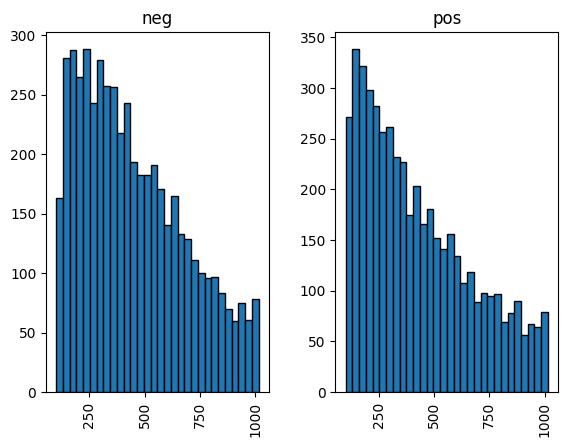

In [26]:
df.hist('len', by='label', bins=30, edgecolor='black')
plt.show()

In [27]:
def data_clean(data):
    text = ' '.join(re.findall('\w+', data))
    doc  = nlp(text)
    cleaned_text = [
        token.lemma_ for token in doc
        if not token.is_stop and not token.is_punct
        and not token.is_digit and not token.is_bracket
        and not token.is_currency and token.lemma_ not in STOPWORDS
    ]
    return " ".join(cleaned_text)

<>:2: SyntaxWarning: invalid escape sequence '\w'
<>:2: SyntaxWarning: invalid escape sequence '\w'
/tmp/ipykernel_181/1551600621.py:2: SyntaxWarning: invalid escape sequence '\w'
  text = ' '.join(re.findall('\w+', data))


In [29]:
df["review"] = df["review"].apply(data_clean)

In [ ]:
def word_cloud(image):
    plt.figure(figsize=(10, 10))
    plt.imshow(image)
    plt.axis("off")
    plt.show()

In [ ]:
doc  = [i.strip() for i in df["review"]]
text = " ".join(doc)

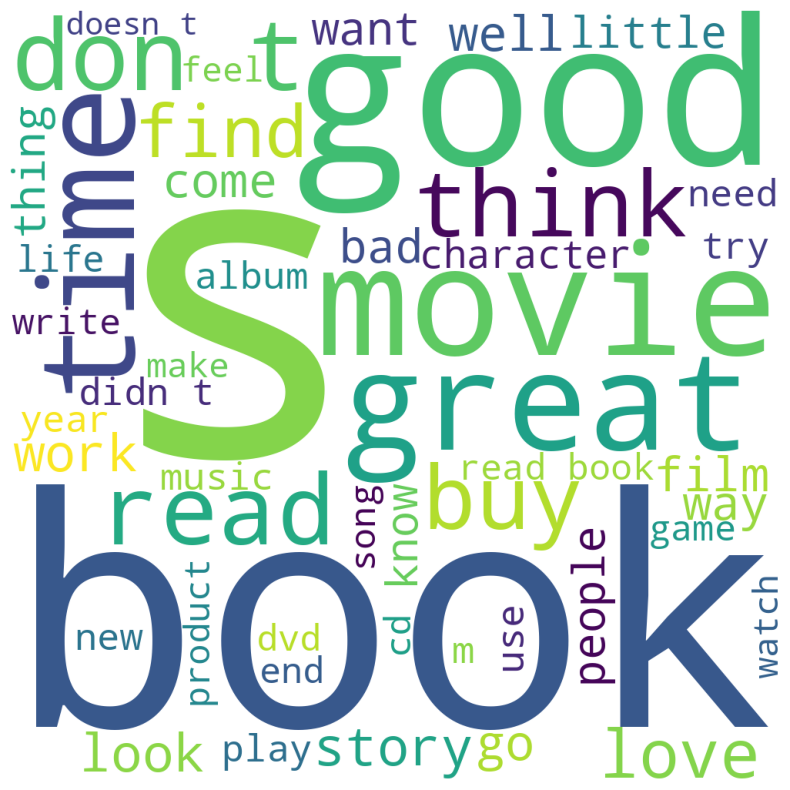

In [47]:
word_cl = WordCloud(width=1000, height=1000,
                    background_color="white", max_words=50).generate(text)
word_cloud(word_cl)

In [48]:
def blob_value(txt):
    return TextBlob(txt).sentiment.polarity

def vader_sentiment(txt):
    vader = SentimentIntensityAnalyzer()
    return vader.polarity_scores(txt)["compound"]

'''
Compound score interpretation:
  -1.0 to -0.05  => Negative
  -0.05 to  0.05 => Neutral
   0.05 to  1.0  => Positive
'''

'\nCompound score interpretation:\n  -1.0 to -0.05  => Negative\n  -0.05 to  0.05 => Neutral\n   0.05 to  1.0  => Positive\n'

In [49]:
vader = SentimentIntensityAnalyzer()  # create once outside the loop

wordRecord = {}

# nlp.pipe() processes all reviews in batches — much faster than calling nlp() one by one
for doc in nlp.pipe(df["review"], batch_size=500):
    for token in doc:
        word = token.lemma_.lower()
        if word not in wordRecord:
            # compute VADER score only once per unique word
            wordRecord[word] = {
                "count": 0,
                "score": vader.polarity_scores(word)["compound"]
            }
        wordRecord[word]["count"] += 1

print(f"Unique words tracked: {len(wordRecord)}")

Unique words tracked: 25678


In [54]:
def vader_sentiment(txt):
    return vader.polarity_scores(txt)["compound"]

In [55]:
wordDf = pd.DataFrame.from_dict(wordRecord, orient="index")
wordDf = wordDf.reset_index().rename(columns={"index": "word"})
print(len(wordDf))
wordDf.head()

25678


,word,count,score
0,stun,4,0.0
1,non,142,0.0
2,gamer,4,0.0
3,sound,706,0.0
4,track,375,0.0


In [56]:
# Most positive and negative words
print(wordDf[wordDf["score"] == wordDf["score"].max()])
print(wordDf[wordDf["score"] == wordDf["score"].min()])

                word  count   score
3888             aml      1  0.6597
19218  magnificently      2  0.6597
         word  count   score
19012  rapist      2 -0.7096


In [57]:
# Most common positive and negative words
positiveWords = wordDf[wordDf["score"] >  0.05]
negativeWords = wordDf[wordDf["score"] < -0.05]
print(positiveWords[positiveWords["count"] == positiveWords["count"].max()])
print(negativeWords[negativeWords["count"] == negativeWords["count"].max()])

    word  count   score
18  good   3806  0.4404
    word  count   score
221  bad   1480 -0.5423


# 2. Model Building – TF-IDF + Random Forest (Baseline)

In [58]:
df.head()

,label,review,len
1,pos,stun non gamer sound track beautiful paint sen...,426
2,pos,good soundtrack m read lot review say good gam...,509
3,pos,amazing soundtrack favorite music time hand in...,760
4,pos,Excellent Soundtrack truly soundtrack enjoy vi...,743
5,pos,remember pull Jaw floor hear ve play game know...,481


In [59]:
# Train / test split
x_train, x_test, y_train, y_test = train_test_split(
    df['review'], df['label'], train_size=0.8, random_state=100)
print(x_train.shape, x_test.shape)

(8000,) (2000,)


In [61]:
# TF-IDF pipeline with Random Forest
pipeline = Pipeline([
    ('tfidf',      TfidfVectorizer(ngram_range=(1, 1))),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

In [62]:
pipeline.fit(x_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer()),
                ('classifier', RandomForestClassifier(random_state=42))])

In [63]:
y_pred = pipeline.predict(x_test)
print("TF-IDF + Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))

TF-IDF + Random Forest Accuracy: 0.835

              precision    recall  f1-score   support

         neg       0.84      0.83      0.83       991
         pos       0.83      0.84      0.84      1009

    accuracy                           0.83      2000
   macro avg       0.84      0.83      0.83      2000
weighted avg       0.84      0.83      0.83      2000



# 3. Advanced NLP – Word2Vec Embeddings

In [65]:
# Tokenise each review into a list of words for Word2Vec training
tokenized_reviews = [review.split() for review in df['review']]

# Train Word2Vec model
w2v_model = Word2Vec(
    sentences=tokenized_reviews,
    vector_size=100,   # embedding dimension
    window=5,          # context window size
    min_count=1,       # ignore words with freq < min_count
    workers=4,
    epochs=10,
    seed=42
)
print("Word2Vec vocabulary size:", len(w2v_model.wv))
print("Sample vector for 'good':", w2v_model.wv['good'][:5], "...")

Word2Vec vocabulary size: 31696
Sample vector for 'good': [ 0.17175823  0.01648177 -1.1927305  -0.2028375  -0.5148869 ] ...


In [66]:
# Convert each review to its average Word2Vec vector
def document_vector(doc, model, vector_size=100):
    """Return the mean of all word vectors in the document."""
    words = doc.split()
    vectors = [model.wv[w] for w in words if w in model.wv]
    if vectors:
        return np.mean(vectors, axis=0)
    return np.zeros(vector_size)

X_w2v       = np.array([document_vector(r, w2v_model) for r in df['review']])
print("Word2Vec feature matrix shape:", X_w2v.shape)

Word2Vec feature matrix shape: (10000, 100)


In [67]:
# Encode string labels  (pos -> 1, neg -> 0)
le = LabelEncoder()
y_encoded = le.fit_transform(df['label'])
print("Classes:", le.classes_)   # e.g. ['__label__1' '__label__2'] or ['neg' 'pos']

# Train / test split on Word2Vec features
X_train_w2v, X_test_w2v, y_train_w2v, y_test_w2v = train_test_split(
    X_w2v, y_encoded, train_size=0.8, random_state=100)
print("Train:", X_train_w2v.shape, "  Test:", X_test_w2v.shape)

Classes: ['neg' 'pos']
Train: (8000, 100)   Test: (2000, 100)


In [68]:
# Quick baseline – Random Forest on Word2Vec vectors
rf_w2v = RandomForestClassifier(n_estimators=100, random_state=42)
rf_w2v.fit(X_train_w2v, y_train_w2v)
y_pred_w2v_rf = rf_w2v.predict(X_test_w2v)

print("Word2Vec + Random Forest Accuracy:", accuracy_score(y_test_w2v, y_pred_w2v_rf))
print()
print(classification_report(y_test_w2v, y_pred_w2v_rf))

Word2Vec + Random Forest Accuracy: 0.76

              precision    recall  f1-score   support

           0       0.75      0.77      0.76       991
           1       0.77      0.75      0.76      1009

    accuracy                           0.76      2000
   macro avg       0.76      0.76      0.76      2000
weighted avg       0.76      0.76      0.76      2000



# 4. Neural Network on Word2Vec Embeddings

In [69]:
# Build a fully-connected neural network on top of Word2Vec features
def build_nn(input_dim):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_dim,)),
        Dropout(0.3),
        Dense(64,  activation='relu'),
        Dropout(0.3),
        Dense(32,  activation='relu'),
        Dense(1,   activation='sigmoid')          # binary classification
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

nn_model = build_nn(X_train_w2v.shape[1])
nn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,297 (91.00 KB)

 Trainable params: 23,297 (91.00 KB)

 Non-trainable params: 0 (0.00 B)

In [70]:
early_stop = EarlyStopping(
    monitor='val_accuracy', patience=5, restore_best_weights=True)

history = nn_model.fit(
    X_train_w2v, y_train_w2v,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_w2v, y_test_w2v),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7031 - loss: 0.5646 - val_accuracy: 0.7610 - val_loss: 0.5036
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7564 - loss: 0.5080 - val_accuracy: 0.7570 - val_loss: 0.4974
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7602 - loss: 0.4949 - val_accuracy: 0.7660 - val_loss: 0.4886
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7678 - loss: 0.4898 - val_accuracy: 0.7580 - val_loss: 0.4922
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7707 - loss: 0.4805 - val_accuracy: 0.7705 - val_loss: 0.4827
Epoch 6/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7774 - loss: 0.4735 - val_accuracy: 0.7655 - val_loss: 0.4857
Epoch 7/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7745 - loss: 0.4741 - val_accuracy: 0.7715 - val_loss: 0.4878
Epoch 8/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7753 - loss: 0.4728 - val_accuracy: 0.

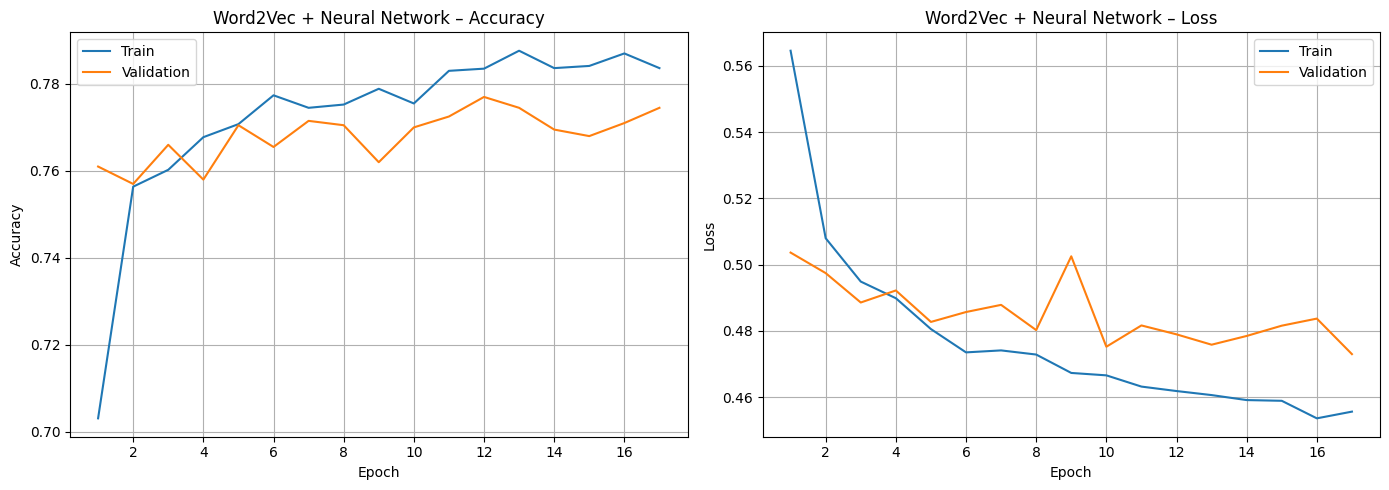

In [71]:
# Learning curves
last = history.epoch[-1] + 2
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, last), history.history['accuracy'],     label='Train')
axes[0].plot(range(1, last), history.history['val_accuracy'], label='Validation')
axes[0].set_title('Word2Vec + Neural Network – Accuracy')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(range(1, last), history.history['loss'],     label='Train')
axes[1].plot(range(1, last), history.history['val_loss'], label='Validation')
axes[1].set_title('Word2Vec + Neural Network – Loss')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()

In [72]:
# Evaluate Neural Network
y_pred_nn_prob = nn_model.predict(X_test_w2v)
y_pred_nn      = (y_pred_nn_prob > 0.5).astype(int).flatten()

print("Word2Vec + Neural Network Accuracy:", accuracy_score(y_test_w2v, y_pred_nn))
print()
print(classification_report(y_test_w2v, y_pred_nn,
                             target_names=le.classes_))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Word2Vec + Neural Network Accuracy: 0.777

              precision    recall  f1-score   support

         neg       0.82      0.70      0.76       991
         pos       0.74      0.85      0.79      1009

    accuracy                           0.78      2000
   macro avg       0.78      0.78      0.78      2000
weighted avg       0.78      0.78      0.78      2000



# 5. Model Comparison

  TF-IDF + RF (baseline)               0.8350
  Word2Vec + RF                        0.7600
  Word2Vec + Neural Network            0.7770


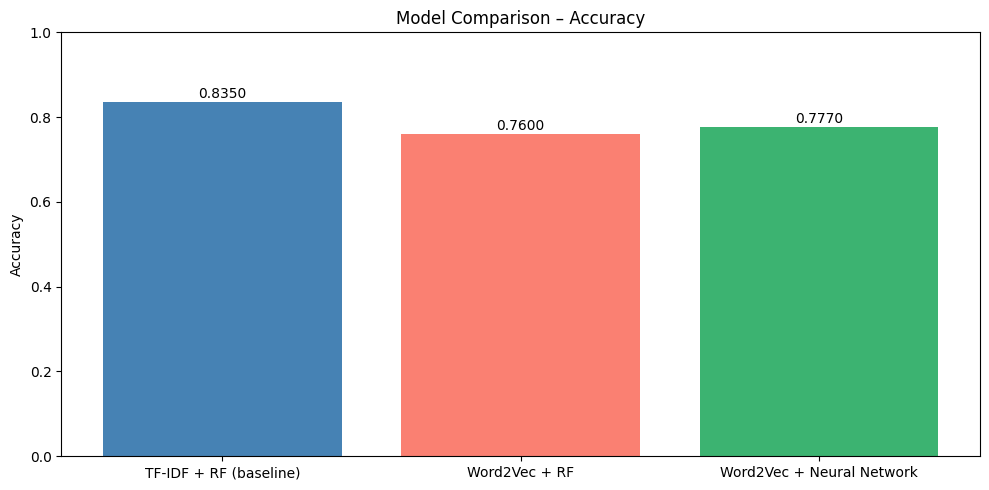

In [73]:
# Compare all three models
models      = ['TF-IDF + RF (baseline)',
               'Word2Vec + RF',
               'Word2Vec + Neural Network']
accuracies  = [
    accuracy_score(y_test,     y_pred),
    accuracy_score(y_test_w2v, y_pred_w2v_rf),
    accuracy_score(y_test_w2v, y_pred_nn)
]

print("=" * 50)
for m, a in zip(models, accuracies):
    print(f"  {m:<35}  {a:.4f}")
print("=" * 50)

# Bar chart
plt.figure(figsize=(10, 5))
bars = plt.bar(models, accuracies, color=['steelblue', 'salmon', 'mediumseagreen'])
plt.ylabel('Accuracy')
plt.title('Model Comparison – Accuracy')
plt.ylim(0, 1)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, acc + 0.01,
             f'{acc:.4f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

### Summary

| Model | Technique | Notes |
|---|---|---|
| **TF-IDF + Random Forest** | Sparse bag-of-words features | Fast baseline; no word meaning captured |
| **Word2Vec + Random Forest** | Dense 100-d embeddings (avg pool) | Captures semantic meaning of words |
| **Word2Vec + Neural Network** | Dense embeddings + 3-layer MLP | Learns non-linear patterns; best potential |

**Key observations:**
- Word2Vec captures semantic relationships between words (e.g. "good" and "great" have similar vectors), which TF-IDF cannot.
- The Neural Network on Word2Vec embeddings can learn non-linear decision boundaries that a Random Forest may miss.
- Average-pooling Word2Vec vectors loses word order — a more advanced approach (LSTM, BERT) would preserve sequence information.
- EarlyStopping with `restore_best_weights=True` prevents overfitting on the Neural Network.